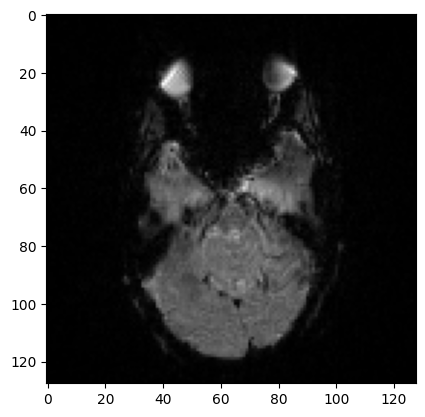

In [1]:
import pydicom
import matplotlib.pyplot as plt

ds = pydicom.dcmread("../data/upenn_gbm/UPENN-GBM-00001/1.3.6.1.4.1.14519.5.2.1.27626308777696377724750002938243956383/1.3.6.1.4.1.14519.5.2.1.202685500194820733902722321770171989719/0a2b09c3-9cce-46db-b0a2-d5e86e07ff1f.dcm")

plt.imshow(ds.pixel_array, cmap="gray")
plt.show()

In [5]:
import os

root = "../data/upenn_gbm"

results = []

for patient in sorted(os.listdir(root)):
    patient_path = os.path.join(root, patient)

    if not os.path.isdir(patient_path):
        continue

    num_series = 0
    num_dcm = 0

    # recorrer TODO recursivamente
    for dirpath, dirnames, filenames in os.walk(patient_path):

        # contar series como carpetas que contienen DICOM
        dcm_files = [f for f in filenames if f.lower().endswith(".dcm")]

        if len(dcm_files) > 0:
            num_series += 1
            num_dcm += len(dcm_files)

    results.append((patient, num_series, num_dcm))


for patient, n_series, n_dcm in results:
    print(f"{patient}: {n_series} carpetas con DICOM, {n_dcm} archivos DCM")


print("\n--- RESUMEN ---")
print(f"Pacientes: {len(results)}")
print(f"Total series (aprox): {sum(r[1] for r in results)}")
print(f"Total DCM: {sum(r[2] for r in results)}")

UPENN-GBM-00001: 6 carpetas con DICOM, 1614 archivos DCM
UPENN-GBM-00002: 6 carpetas con DICOM, 1978 archivos DCM
UPENN-GBM-00003: 6 carpetas con DICOM, 1629 archivos DCM
UPENN-GBM-00004: 6 carpetas con DICOM, 1614 archivos DCM
UPENN-GBM-00005: 6 carpetas con DICOM, 1614 archivos DCM
UPENN-GBM-00006: 6 carpetas con DICOM, 1614 archivos DCM
UPENN-GBM-00007: 6 carpetas con DICOM, 1978 archivos DCM
UPENN-GBM-00008: 6 carpetas con DICOM, 1978 archivos DCM
UPENN-GBM-00009: 6 carpetas con DICOM, 1629 archivos DCM
UPENN-GBM-00010: 6 carpetas con DICOM, 1749 archivos DCM
UPENN-GBM-00011: 5 carpetas con DICOM, 714 archivos DCM
UPENN-GBM-00012: 6 carpetas con DICOM, 1629 archivos DCM
UPENN-GBM-00013: 5 carpetas con DICOM, 729 archivos DCM
UPENN-GBM-00014: 6 carpetas con DICOM, 1629 archivos DCM
UPENN-GBM-00015: 6 carpetas con DICOM, 1629 archivos DCM
UPENN-GBM-00016: 6 carpetas con DICOM, 1629 archivos DCM
UPENN-GBM-00017: 5 carpetas con DICOM, 995 archivos DCM
UPENN-GBM-00018: 6 carpetas con DI


Serie: 1.3.6.1.4.1.14519.5.2.1.331973553483442583805042634114737877712
Total DICOM: 192 | mostrando 5


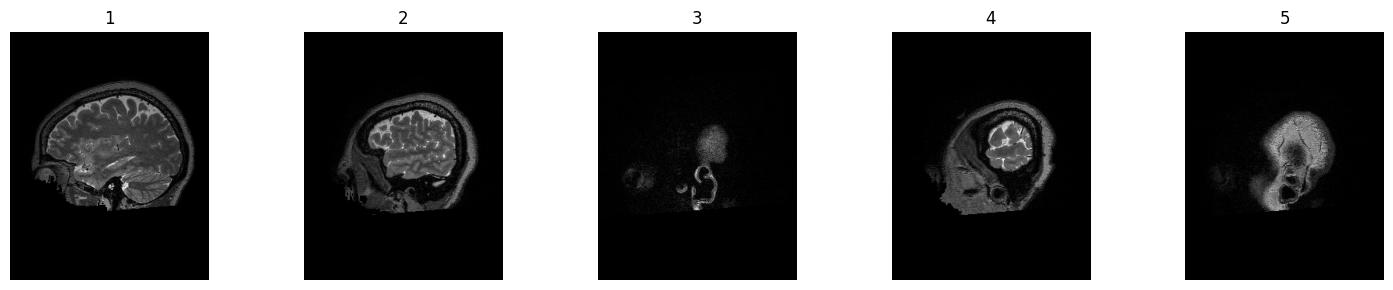


Serie: 1.3.6.1.4.1.14519.5.2.1.303922662365557240161187739636975756435
Total DICOM: 192 | mostrando 5


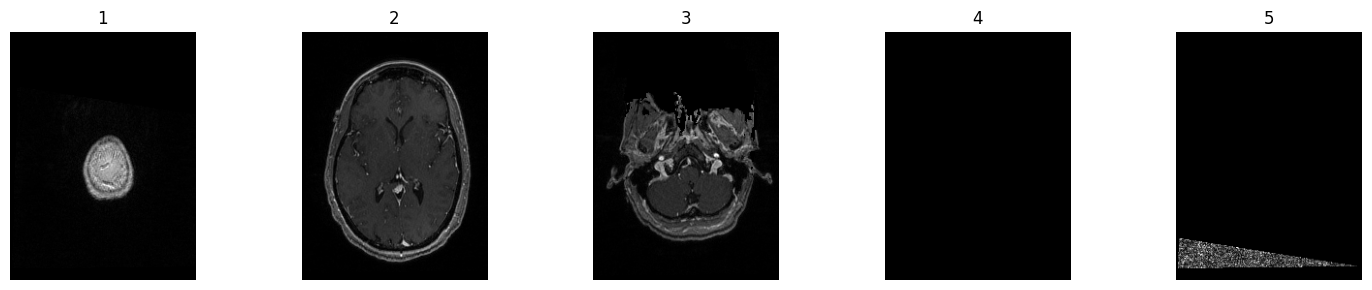


Serie: 1.3.6.1.4.1.14519.5.2.1.27626308777696377724750002938243956383
Total DICOM: 900 | mostrando 5


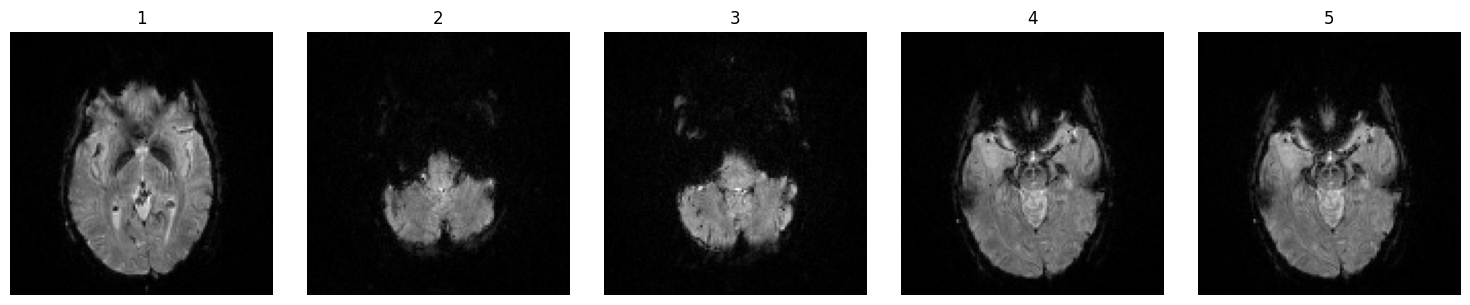


Serie: 1.3.6.1.4.1.14519.5.2.1.193084931700557478622366870650889741468
Total DICOM: 78 | mostrando 5


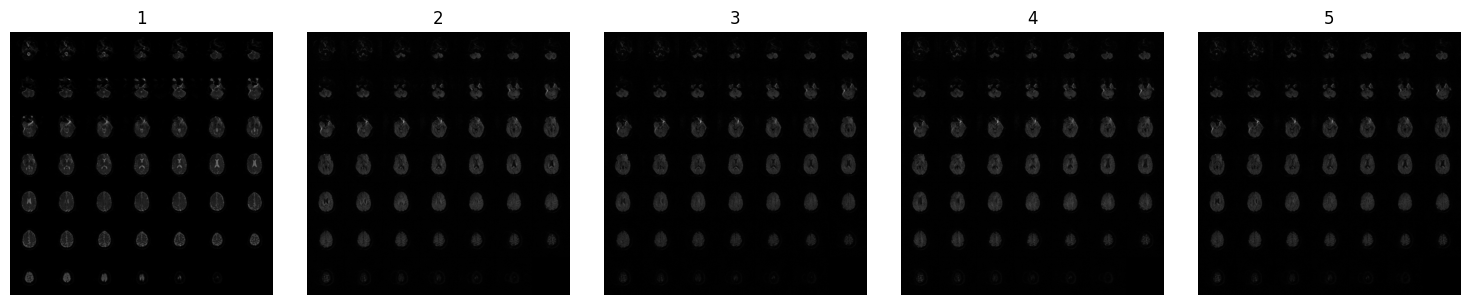


Serie: 1.3.6.1.4.1.14519.5.2.1.49170894934501988654429652847391687414
Total DICOM: 192 | mostrando 5


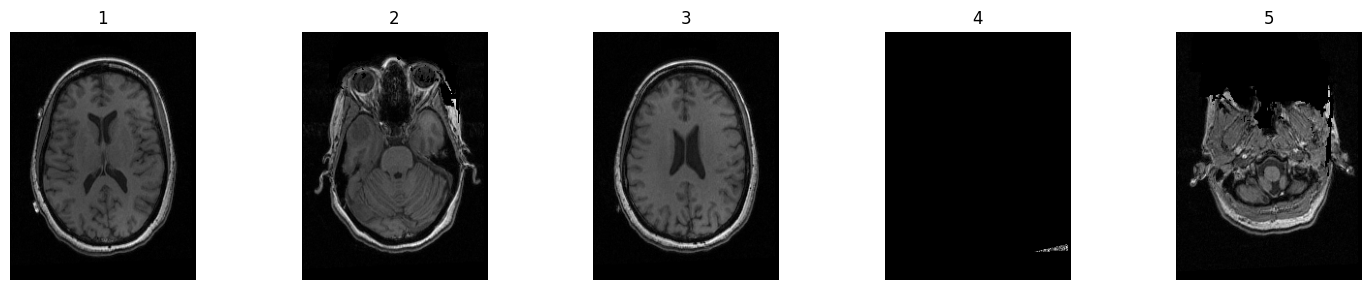


Serie: 1.3.6.1.4.1.14519.5.2.1.325722981077189157104874710559665333106
Total DICOM: 60 | mostrando 5


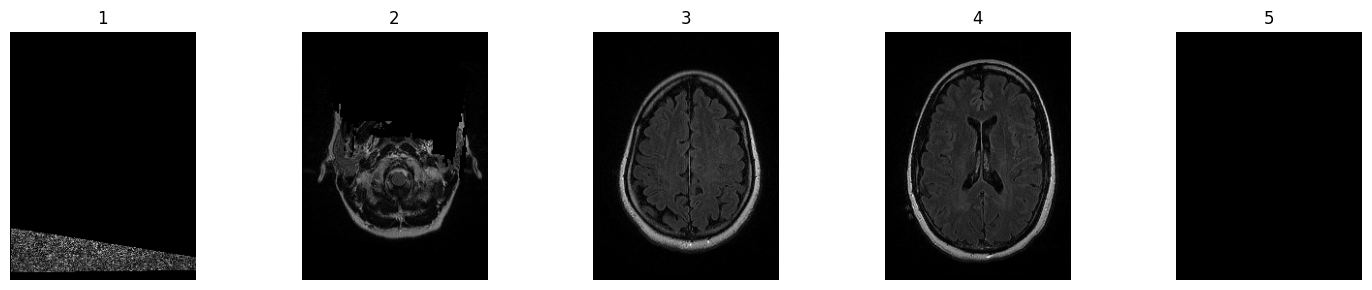

In [ ]:
import os
import pydicom
import matplotlib.pyplot as plt

patient_path = "../data/upenn_gbm/UPENN-GBM-00001"

series_list = [
    os.path.join(patient_path, d)
    for d in os.listdir(patient_path)
    if os.path.isdir(os.path.join(patient_path, d))
]

for series_path in series_list:

    dicom_files = []

    # 🔍 buscar DICOM en toda la jerarquía de la serie
    for dirpath, _, filenames in os.walk(series_path):
        for f in filenames:
            if f.lower().endswith(".dcm"):
                dicom_files.append(os.path.join(dirpath, f))

    dicom_files = sorted(dicom_files)

    if len(dicom_files) == 0:
        continue

    # tomar 5
    sample = dicom_files[:5]

    print(f"\nSerie: {os.path.basename(series_path)}")
    print(f"Total DICOM: {len(dicom_files)} | mostrando 5")

    plt.figure(figsize=(15, 3))

    for i, file in enumerate(sample):
        ds = pydicom.dcmread(file)
        
        plt.subplot(1, 5, i + 1)
        plt.imshow(ds.pixel_array, cmap="gray")
        plt.title(f"{i+1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [12]:
import pandas as pd

# Cargar el CSV
df = pd.read_csv("../data/metadata/UPENN-GBM_DownloadManifest20221129-nbia-digest(Metadata).csv", sep=";")

# 1. Número de filas
print("Número de filas:", len(df))

# 2. Columnas (primera fila = encabezados)
print("Columnas:")
for col in df.columns:
    print(col)

# 3. Ver valores de la primera fila
print("\nPrimera fila:")
print(df.iloc[0])

Número de filas: 3680
Columnas:
Patient ID
Patient Name
Patient Birth Date
Patient Sex
Ethnic Group
Phantom
Species Code
Species Description
Study Instance UID
Study Date
Study Description
Admitting Diagnosis Description
Study ID
Patient Age
Longitudinal Temporal Event Type
Longitudinal Temporal Offset From Event
Series Instance UID
Project
Modality
Protocol Name
Series Date
Series Description
Body Part Examined
Series Number
Annotations Flag
Manufacturer
Manufacturer Model Name
Software Versions
Image Count
Max Submission Timestamp
License Name
License URI
Collection URI
File Size
Date Released
Third Party Analysis

Primera fila:
Patient ID                                                                   UPENN-GBM-00002
Patient Name                                                                 UPENN-GBM-00002
Patient Birth Date                                                                       NaN
Patient Sex                                                                       

In [14]:
import pandas as pd

# Cargar el CSV
df = pd.read_csv("../data/metadata/metadata.csv", sep=",")

# 1. Número de filas
print("Número de filas:", len(df))

# 2. Columnas (primera fila = encabezados)
print("Columnas:")
for col in df.columns:
    print(col)

# 3. Ver valores de la primera fila
print("\nPrimera fila:")
print(df.iloc[0])

Número de filas: 3680
Columnas:
PatientID
PatientName
PatientSex
EthnicGroup
Phantom
SpeciesCode
SpeciesDescription
StudyInstanceUID
StudyDate
StudyDesc
AdmittingDiagnosisDescription
StudyID
PatientAge
LongitudinalTemporalEventType
LongitudinalTemporalOffsetFromEvent
SeriesInstanceUID
Collection
Site
Modality
ProtocolName
SeriesDate
SeriesDescription
BodyPartExamined
SeriesNumber
AnnotationsFlag
Manufacturer
ManufacturerModelName
PixelSpacing(mm)-Row
SliceThickness(mm)
SoftwareVersions
ImageCount
MaxSubmissionTimestamp
LicenseName
LicenseURI
DataDescriptionURI
FileSize
ReleasedStatus
DateReleased
ThirdPartyAnalysis
Authorized
DownloadURL
DRSURI
S5cmdManifestPath
FileName
OriginalS5cmdURI
IsSyncJob

Primera fila:
PatientID                                                                UPENN-GBM-00001
PatientName                                                                          NaN
PatientSex                                                                           NaN
EthnicGroup